In [31]:
# INTRODUCTION

# This notebook performs sentiment analysis on customer reviews.
# The goal is to classify reviews as positive or negative.
# TF-IDF is used to convert text into numerical features.
# Logistic Regression is used to build and evaluate the model.

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
# Sentiment Analysis using TF-IDF and Logistic Regression
# Using mental_health dataset

# Loading the dataset
df = pd.read_csv("mental_health.csv")

In [34]:
# Display first few records for dataset preview
df.head(5)

,statement,status
0,oh my gosh,Anxiety
1,trouble sleeping confused mind restless hear...,Anxiety
2,All wrong back off dear forward doubt. Stay ...,Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,I'm restless and restless it's been a month n...,Anxiety


In [35]:
# Basic information about mental_health dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52682 entries, 0 to 52681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52682 non-null  object
 1   status     52680 non-null  object
dtypes: object(2)
memory usage: 823.3+ KB


In [36]:
# Check class distribution
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10651
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

In [37]:
# Display last few records for dataset preview
df.tail(5)

,statement,status
52677,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
52678,"selfishness ""I don't feel very good it's lik...",Anxiety
52679,Is there any way to sleep better? I can't slee...,Anxiety
52680,Public speaking tips? Hi all. I have to give ...,Anxiety
52681,I have really bad door anxiety! It's not about...,Anxiety


In [38]:
# TEXT PREPROCESSING

# Convert to lowercase
df['statement'] = df['statement'].str.lower()

# Remove special characters
df['statement'] = df['statement'].str.replace('[^a-zA-Z ]', '', regex=True)

In [39]:
# Checking changes in last 5 rows
df.tail(5)

,statement,status
52677,nobody takes me seriously ive m dealt with dep...,Anxiety
52678,selfishness i dont feel very good its like i...,Anxiety
52679,is there any way to sleep better i cant sleep ...,Anxiety
52680,public speaking tips hi all i have to give a ...,Anxiety
52681,i have really bad door anxiety its not about b...,Anxiety


In [40]:
# Check null values
print(df.isnull().sum())

statement    0
status       2
dtype: int64


In [41]:
# Remove missing values
df = df.dropna()

# Remove empty reviews
df = df[df['statement'].str.strip() != '']

In [42]:
# Resetting the index
df = df.reset_index(drop=True)

In [43]:
# Final safety check
print(df.isnull().sum())

statement    0
status       0
dtype: int64


In [44]:
# Defining Features and target
X = df['statement']
y = df['status']

In [45]:
# Spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
# TF-IDF Vectorization

# Convert text to numerical features
tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [47]:
# Training LOGISTIC REGRESSION model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

C:\Users\Sanket M\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [48]:
# Making the predictions
y_pred = model.predict(X_test_tfidf)

In [49]:
# MODEL EVALUATION

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7672520170859042


In [50]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
                       precision    recall  f1-score   support

             Anxiety       0.83      0.77      0.80       777
             Bipolar       0.84      0.72      0.77       527
          Depression       0.71      0.74      0.73      3048
              Normal       0.84      0.95      0.89      3330
Personality disorder       0.84      0.43      0.57       220
              Stress       0.71      0.43      0.53       512
            Suicidal       0.69      0.65      0.67      2121

            accuracy                           0.77     10535
           macro avg       0.78      0.67      0.71     10535
        weighted avg       0.76      0.77      0.76     10535



In [51]:
# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[ 600   10   52   88    3   20    4]
 [  16  379   64   39    4   14   11]
 [  32   35 2255  168    7   20  531]
 [  12   10   81 3153    3   16   55]
 [   8    4   66   25   94   16    7]
 [  48   13   78  131    1  219   22]
 [   3    2  566  165    0    2 1383]]


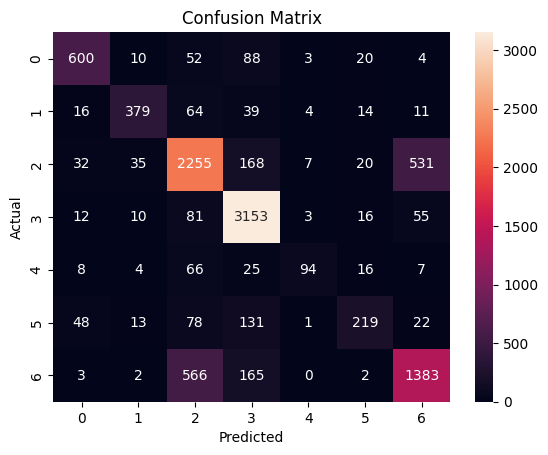

In [52]:
# Plotting graph of confusion matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
# TF-IDF with advanced parameters
tfidf_adv = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X_train_adv = tfidf_adv.fit_transform(X_train)
X_test_adv = tfidf_adv.transform(X_test)

print("TF-IDF shape:", X_train_adv.shape)

TF-IDF shape: (42139, 5000)


In [54]:
# Predict probabilities
probs = model.predict_proba(X_test_tfidf[:5])

for i, prob in enumerate(probs):
    print(f"Sample {i+1} Probabilities:", prob)

Sample 1 Probabilities: [0.00918367 0.01741532 0.44328913 0.00453814 0.00656276 0.00956996
 0.50944102]
Sample 2 Probabilities: [8.79645546e-05 7.02134382e-04 6.54249883e-01 2.19375092e-05
 6.44047308e-04 1.06812105e-03 3.43225912e-01]
Sample 3 Probabilities: [0.00697083 0.01429359 0.59236979 0.13473808 0.02630385 0.06757128
 0.15775258]
Sample 4 Probabilities: [9.29437790e-04 1.67137937e-03 7.51140534e-01 3.32629513e-03
 3.96716009e-04 4.37957288e-04 2.42097681e-01]
Sample 5 Probabilities: [0.01269887 0.00779753 0.69348461 0.18511258 0.00528401 0.01361966
 0.08200274]


In [55]:
# Testing small statement custom reviews
sample_reviews = [
    "All wrong  back off dear  forward doubt. Stay in a restless and restless place",
    "Worst experience ever, very bad quality",
    "just a check in post. I am curious to see how you all are doing how are you?",
    "Completely useless and waste of money",
    "It literally makes me want to vomit when I think about myself I hate myself",
    "I am GOING TO DO IT. I cannot LIVE LIKE THIS PLEASE MAKE IT STOOOP!"
]

# Transform using TF-IDF
sample_tfidf = tfidf.transform(sample_reviews)

# Predict sentiment
predictions = model.predict(sample_tfidf)

# Display results
for review, pred in zip(sample_reviews, predictions):
    print(review, "->", pred)

All wrong  back off dear  forward doubt. Stay in a restless and restless place -> Anxiety
Worst experience ever, very bad quality -> Normal
just a check in post. I am curious to see how you all are doing how are you? -> Depression
Completely useless and waste of money -> Depression
It literally makes me want to vomit when I think about myself I hate myself -> Suicidal
I am GOING TO DO IT. I cannot LIVE LIKE THIS PLEASE MAKE IT STOOOP! -> Normal


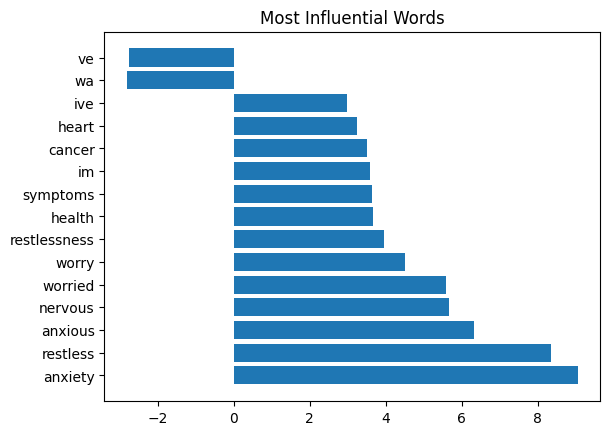

In [56]:
# Plot top influential words
import pandas as pd

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_words = sorted(zip(coefficients, feature_names), key=lambda x: abs(x[0]), reverse=True)[:15]

words = [w for _, w in top_words]
scores = [s for s, _ in top_words]

plt.figure()
plt.barh(words, scores)
plt.title("Most Influential Words")
plt.show()

In [57]:
# TOP IMPORTANT WORDS

# Get feature importance
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

# Top positive words
top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]

# Top negative words
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("Top Positive Words:\n")
for score, word in top_positive:
    print(f"{word} -> {score}")

print("\nTop Negative Words:\n")
for score, word in top_negative:
    print(f"{word} -> {score}")

Top Positive Words:

anxiety -> 9.055758598906028
restless -> 8.359653320404108
anxious -> 6.3295857234401405
nervous -> 5.652656155818941
worried -> 5.595784255555001
worry -> 4.500985983390932
restlessness -> 3.957907142260926
health -> 3.6739762903348137
symptoms -> 3.625316564749714
im -> 3.5975680832894086

Top Negative Words:

wa -> -2.8067149624056453
ve -> -2.747668043130275
depression -> -2.590216164533908
bipolar -> -2.489145028895107
want -> -2.147702958915626
suicidal -> -2.1025470058599733
don -> -1.9549348129415924
stress -> -1.8593916748236143
suicide -> -1.8582185006578693
depressed -> -1.840891239279283


In [58]:
# Overfitting check
train_acc = model.score(X_train_tfidf, y_train)
test_acc = model.score(X_test_tfidf, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8406227010607751
Testing Accuracy: 0.7672520170859042


In [59]:
# CONCLUSION

# The model successfully classified customer reviews into sentiments.
# TF-IDF effectively converted text into meaningful numerical features.
# Logistic Regression provided good accuracy and interpretability.
# This approach is useful for real-world text classification tasks.